# DEMO K-Means Clustering

### - Customer Segmentation (K-Means Clustering)
### - Image compression
### - K-Means Non-spherical

In [1]:
"""
===============================================================
Required Libraries for execute this this DEMO
===============================================================
"""

%pip install kagglehub                      # To get Kaggle Dataset 
%pip install 'kagglehub[pandas-datasets]'   # Required to manipulate Dataset from Kaggle
%pip install matplotlib                     # Graphs 
%pip install scikit-learn                   # Machine Learning
%pip install imageio                        # Generate Gifs


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
"""
===============================================================
Imported Libraries Dataset
===============================================================
"""
# Dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Data manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Machine Learning / Kmeans
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Helpers
import os
import imageio
from matplotlib.animation import FuncAnimation
from IPython.display import HTML



In [3]:
"""
===============================================================
First Example Customer Segmentation (Shopping Mall)

Features
    - Age
    - * Annual Income 
    - * Spending Score (Represents how much the customer spends)

    * used for this demo

Goal: Use k-Means to discover types of customers automatically.

For example, the algorithm might discover groups like:
	•	💰 High income / high spenders → VIP customers
	•	💰 High income / low spenders → potential marketing targets
	•	💵 Low income / high spenders → impulsive buyers
	•	💵 Low income / low spenders → occasional buyers

===============================================================
"""

"""
===============================================================
Step 1. Load Dataset
===============================================================
"""
# Set the path to the file you'd like to load
file_path = "Mall_Customers.csv"

# Load the latest version
dfCustomer_Mall = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    #"vjchoudhary7/customer-segmentation-tutorial-in-python",
    "abdallahwagih/mall-customers-segmentation",
    file_path,
)

#print("First 5 records:", df.head())
dfCustomer_Mall.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


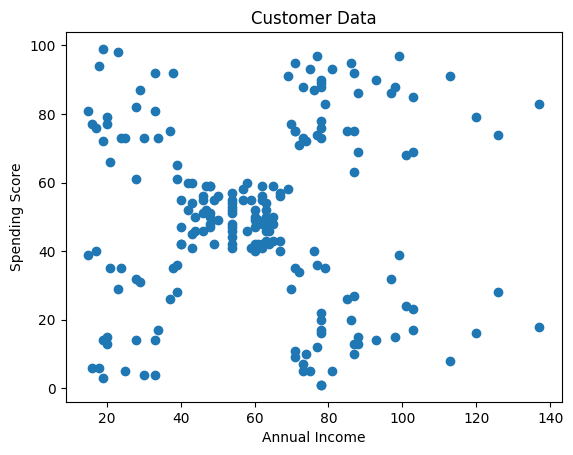

In [4]:
"""
===============================================================
Step 2 Data visualization
===============================================================
"""

# Select features
X_visualization_wa_clusters = dfCustomer_Mall[['Annual Income (k$)', 'Spending Score (1-100)']]

# Plot original data
plt.scatter(X_visualization_wa_clusters['Annual Income (k$)'], X_visualization_wa_clusters['Spending Score (1-100)'])
plt.title("Customer Data")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

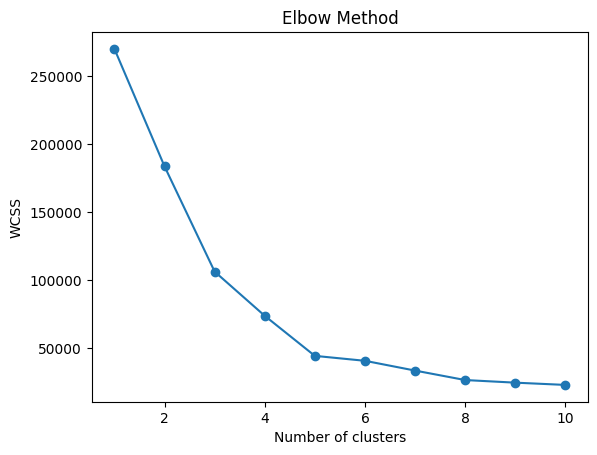

In [5]:
"""
===============================================================
Step 3 Elbow Method

    - WCSS = distance from points to their centroid
    - Lower is better
    - The elbow indicates optimal clusters
    

===============================================================
"""

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_visualization_wa_clusters)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [6]:
"""
===============================================================
Now we are going to step by step showing the Lloyd Algorithm:

Initialize -> Assign -> Update -> Repeat

In this example we are going to use two features 
    - Annual Income
    - Spending score
===============================================================
"""
X_CM = dfCustomer_Mall[['Annual Income (k$)', 'Spending Score (1-100)']].values
X_CM

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [7]:
"""
===============================================================
Start initializing k-means parameters
===============================================================
"""

k = 5 

np.random.seed(42)
centroids = X_CM[np.random.choice(len(X_CM), k, replace=False)]


Text(0.5, 1.0, 'K-Means Clustering Step 1')

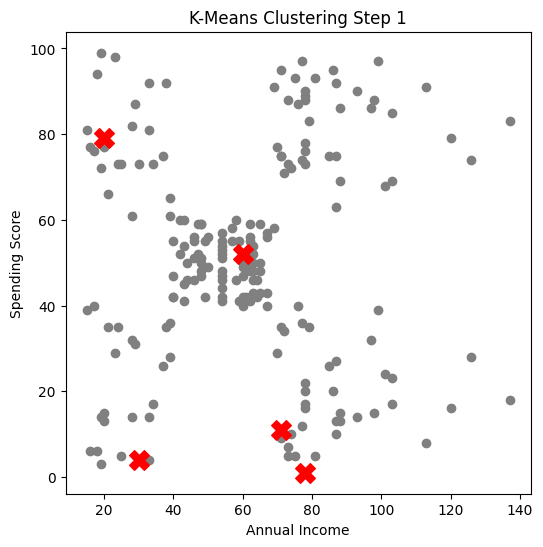

In [8]:
"""
===============================================================
Just to review the initial centroids
===============================================================
"""
fig, ax = plt.subplots(figsize=(6,6))

scatter = ax.scatter(X_CM[:,0], X_CM[:,1], c='gray')
centroid_plot = ax.scatter(centroids[:,0], centroids[:,1],
                            c='red', s=200, marker='X')

ax.set_xlabel("Annual Income")
ax.set_ylabel("Spending Score")
ax.set_title("K-Means Clustering Step 1")

In [9]:
"""
===============================================================
Definition of update function 

Note: The number of iterations is not fixed beforehand. 
The algorithm stops when it converges (When centroids stop changing or change very little).
===============================================================
"""
def update(frame):
    global centroids
    
    clusters = []

    # Assign points to nearest centroid
    # each x is a customer
    for x in X_CM:
        # we compute distances to each centroid using eucledean distance
        distances = [np.linalg.norm(x - c) for c in centroids]
        # Choose the closest centroid
        cluster = np.argmin(distances)
        # Assignment
        clusters.append(cluster)

    clusters = np.array(clusters)
    

    # Update scatter colors
    scatter.set_array(clusters)

    # Move centroids
    new_centroids = []

    # Update step
    # We compute the mean to calculate new centroids
    for i in range(k):
        new_centroids.append(X_CM[clusters == i].mean(axis=0))

    centroids = np.array(new_centroids)

    centroid_plot.set_offsets(centroids)

    ax.set_title(f"K-Means Iteration {frame+1}")

In [10]:
"""
===============================================================
Just for watch animation of k-means
===============================================================
"""
# Repeat
anim = FuncAnimation(fig, update, frames=10, interval=1500)
HTML(anim.to_jshtml())


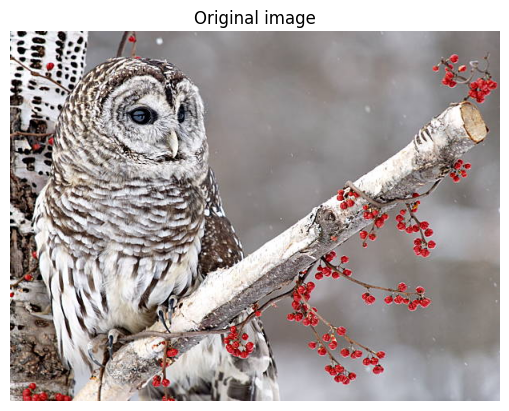

In [11]:
"""
===============================================================
Image Compression

Images has hundreds of thousands of pixels. An image is just a matrix of pixels, 
and each pixel has 3 values:
	•	Red (R)
	•	Green (G)
	•	Blue (B)

So every pixel is a 3-dimensional vector:

K-Means can cluster similar colors together.

Instead of storing millions of colors, we store only K representative colors.

Example

|   K   |   Result                  |
|   256 |  Almost identical image   |
|   64  |  Slight compression       |
|   16  |  Very noticeable palette  |
|   8   |  Cartoon-like             |

===============================================================
"""

# image = plt.imread("winter_fox.webp")
image = plt.imread("buho.jpg")

plt.imshow(image)
plt.title("Original image")
plt.axis("off")
plt.show()

In [12]:
"""
===============================================================
We reshape the image into a list of pixels. 
Now each row represents a pixel of color
===============================================================
"""
pixels = image.reshape(-1,3)
pixels

array([[130, 142, 140],
       [190, 200, 199],
       [218, 228, 227],
       ...,
       [187, 189, 201],
       [189, 191, 203],
       [191, 193, 205]], shape=(282744, 3), dtype=uint8)

In [13]:
"""
===============================================================
Applying K-Means using sklearn
===============================================================
"""

k = 8
# k = 256

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixels)

"""
===============================================================
Now we replace each pixel with its centroid color
Then we reshape the image back
===============================================================
"""
compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]

compressed_image = compressed_pixels.reshape(image.shape)

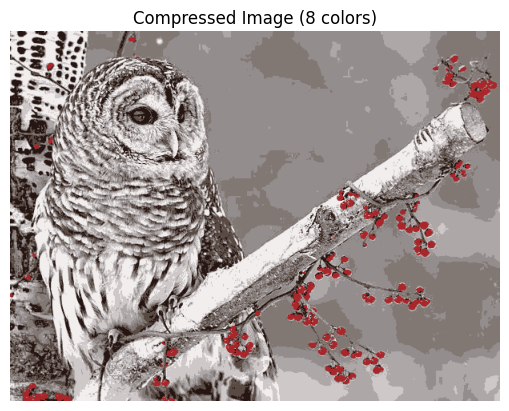

In [14]:
"""
===============================================================
Image applying K-Means for compressing image
===============================================================
"""

plt.imshow(compressed_image.astype(int))
plt.title(f"Compressed Image ({k} colors)")
plt.axis("off")
plt.show()

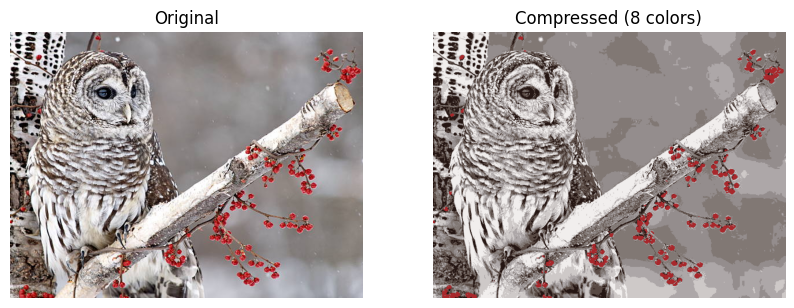

In [15]:
"""
===============================================================
Just to show image in the same plot
===============================================================
"""

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(image)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(compressed_image.astype(int))
ax[1].set_title(f"Compressed ({k} colors)")
ax[1].axis("off")

plt.show()

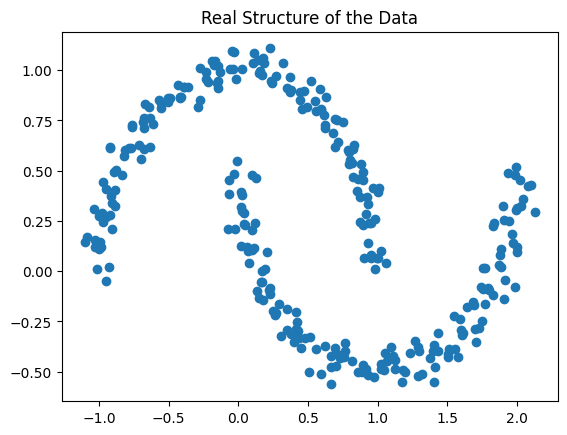

In [16]:
"""
===============================================================
When K-Means fail.

K-Means works well only when clusters are roughly spherical and evenly sized.
If Data has irregular shapes, K-Means may produce wrong clusters

In this example I going to use "two moons" dataset within sklearn
===============================================================
"""
# We generate non-spherical data
X_Moon, y = make_moons(n_samples=300, noise=0.05, random_state=42)

plt.scatter(X_Moon[:,0], X_Moon[:,1])
plt.title("Real Structure of the Data")
plt.show()



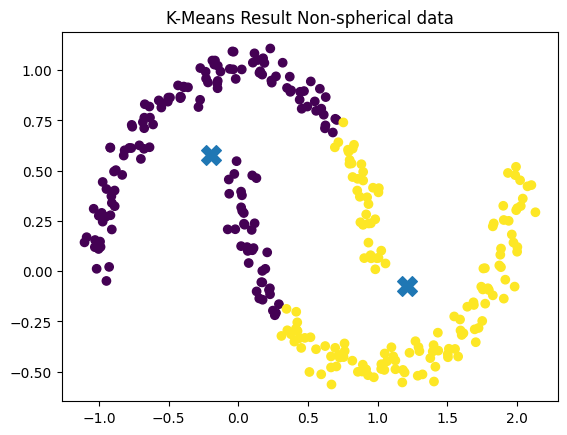

In [17]:
"""
===============================================================
Applying K-Means with 2 clusters
===============================================================
"""
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_Moon)

plt.scatter(X_Moon[:,0],X_Moon[:,1], c=labels, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], s=200, marker='X')

plt.title("K-Means Result Non-spherical data")
plt.show()

In [ ]:
# """
# 4 Distance function
# """

# def compute_distance(a,b):
#     return np.sqrt(((a-b) ** 2).sum(axis=1))



In [ ]:
# # 1. Scale the data
# X_scaled = StandardScaler().fit_transform(X)

# # 2. Elbow method
# inertias = []
# for k in range(1, 11):
#     km = KMeans(n_clusters=k, random_state=42, n_init='auto')
#     inertias.append(km.fit(X_scaled).inertia_)

# # 3. Fit best model
# kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
# labels = kmeans.fit_predict(X_scaled)

# # 4. Evaluate
# score = silhouette_score(X_scaled, labels)
# print(f'Silhouette: {score:.3f}')
